In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import shutil
from torchvision import datasets
from sklearn.model_selection import train_test_split

# Define the path to the original dataset and the new directory to save the splits
dataset_dir = '/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset'
output_dir = '/kaggle/working/split_dataset'

# Create output directories for train, validation, and test splits
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

# Make sure the directories exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root=dataset_dir)

# Create a split for 80% training, 10% validation, and 10% test using sklearn's train_test_split
# Split images and labels
image_paths = [img_path for img_path, _ in dataset.imgs]
labels = [label for _, label in dataset.imgs]

# First split (train + val/test)
train_paths, val_test_paths, train_labels, val_test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

# Second split (val + test)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    val_test_paths, val_test_labels, test_size=0.5, stratify=val_test_labels, random_state=42)

# Function to move images to the corresponding folder
def move_images(image_paths, labels, folder):
    for path, label in zip(image_paths, labels):
        class_name = dataset.classes[label]
        class_dir = os.path.join(folder, class_name)
        os.makedirs(class_dir, exist_ok=True)
        shutil.copy(path, os.path.join(class_dir, os.path.basename(path)))

# Move the files to their respective directories
move_images(train_paths, train_labels, train_dir)
move_images(val_paths, val_labels, val_dir)
move_images(test_paths, test_labels, test_dir)

# Verify that the directories are created and files are moved
print(f"Training set saved to: {train_dir}")
print(f"Validation set saved to: {val_dir}")
print(f"Testing set saved to: {test_dir}")


Training set saved to: /kaggle/working/split_dataset/train
Validation set saved to: /kaggle/working/split_dataset/val
Testing set saved to: /kaggle/working/split_dataset/test



==== Training VGG16 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15 | Train Loss: 0.9131 | Train Acc: 0.5768 | Val Loss: 0.9915 | Val Acc: 0.4938 | Test Loss: 1.0230 | Test Acc: 0.4906
Epoch 2/15 | Train Loss: 0.6091 | Train Acc: 0.7125 | Val Loss: 0.7373 | Val Acc: 0.6703 | Test Loss: 0.7763 | Test Acc: 0.6469
Epoch 3/15 | Train Loss: 0.4869 | Train Acc: 0.7859 | Val Loss: 0.7705 | Val Acc: 0.6703 | Test Loss: 0.9081 | Test Acc: 0.6094
Epoch 4/15 | Train Loss: 0.3919 | Train Acc: 0.8303 | Val Loss: 0.5215 | Val Acc: 0.7984 | Test Loss: 0.5932 | Test Acc: 0.7375
Epoch 5/15 | Train Loss: 0.3131 | Train Acc: 0.8676 | Val Loss: 0.5722 | Val Acc: 0.7375 | Test Loss: 0.6235 | Test Acc: 0.7078
Epoch 6/15 | Train Loss: 0.2462 | Train Acc: 0.8959 | Val Loss: 0.4828 | Val Acc: 0.7969 | Test Loss: 0.5182 | Test Acc: 0.7688
Epoch 7/15 | Train Loss: 0.2063 | Train Acc: 0.9133 | Val Loss: 0.3558 | Val Acc: 0.8531 | Test Loss: 0.3790 | Test Acc: 0.8391
Epoch 8/15 | Train Loss: 0.1528 | Train Acc: 0.9406 | Val Loss: 0.4008 | Val Acc: 0.8406 | Test Loss: 0.

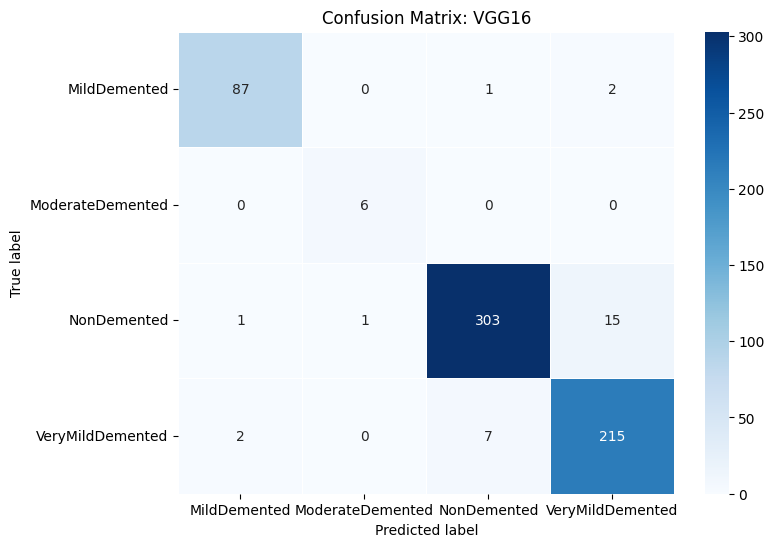

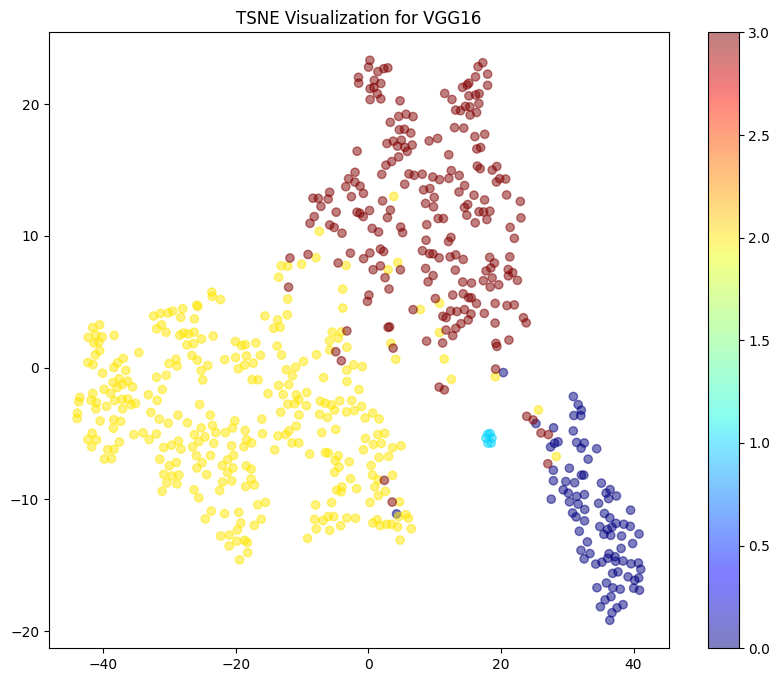

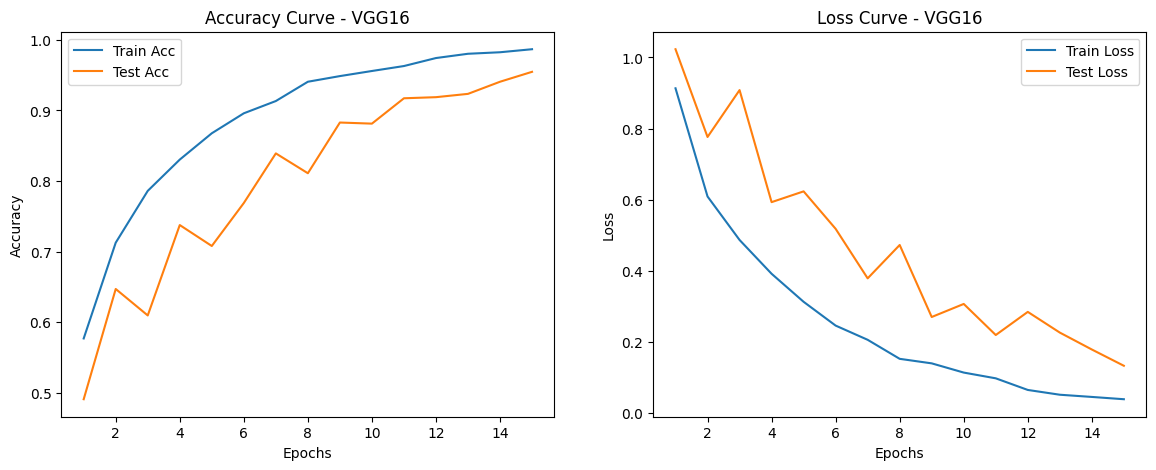


==== Training ResNet18 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15 | Train Loss: 0.8333 | Train Acc: 0.6250 | Val Loss: 0.8072 | Val Acc: 0.6359 | Test Loss: 0.8392 | Test Acc: 0.6125
Epoch 2/15 | Train Loss: 0.5548 | Train Acc: 0.7668 | Val Loss: 0.8110 | Val Acc: 0.6375 | Test Loss: 0.8401 | Test Acc: 0.6406
Epoch 3/15 | Train Loss: 0.4517 | Train Acc: 0.8178 | Val Loss: 0.6594 | Val Acc: 0.7359 | Test Loss: 0.7016 | Test Acc: 0.6828
Epoch 4/15 | Train Loss: 0.3571 | Train Acc: 0.8596 | Val Loss: 0.6332 | Val Acc: 0.7297 | Test Loss: 0.6958 | Test Acc: 0.7266
Epoch 5/15 | Train Loss: 0.2958 | Train Acc: 0.8887 | Val Loss: 0.3875 | Val Acc: 0.8578 | Test Loss: 0.4092 | Test Acc: 0.8359
Epoch 6/15 | Train Loss: 0.2420 | Train Acc: 0.9115 | Val Loss: 0.3831 | Val Acc: 0.8547 | Test Loss: 0.4351 | Test Acc: 0.8375
Epoch 7/15 | Train Loss: 0.1940 | Train Acc: 0.9287 | Val Loss: 0.3652 | Val Acc: 0.8547 | Test Loss: 0.4047 | Test Acc: 0.8328
Epoch 8/15 | Train Loss: 0.1702 | Train Acc: 0.9402 | Val Loss: 0.2941 | Val Acc: 0.8844 | Test Loss: 0.

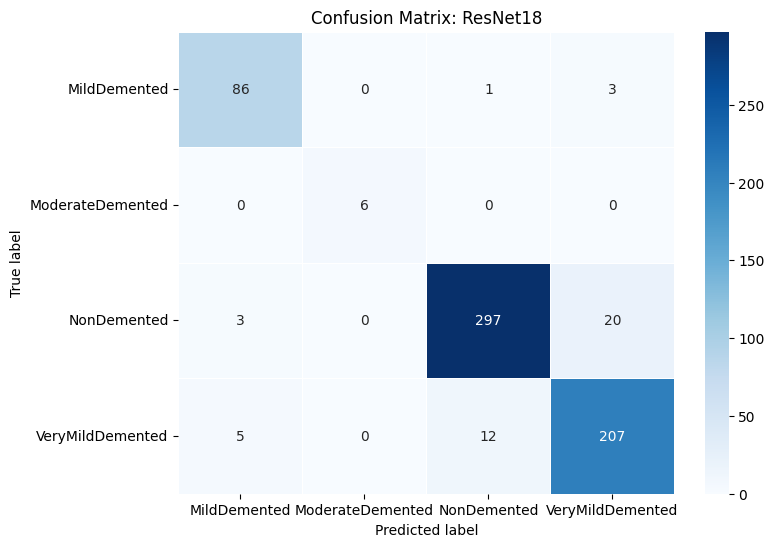

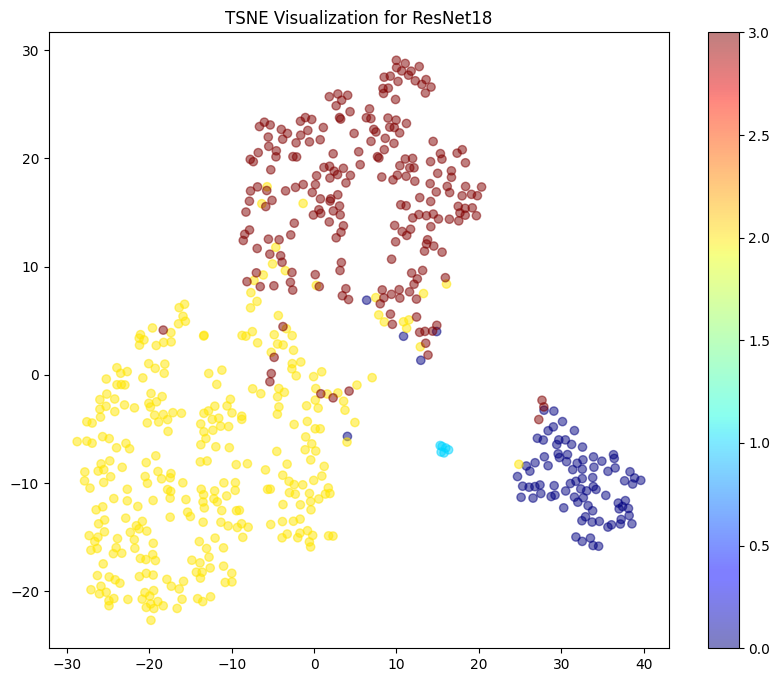

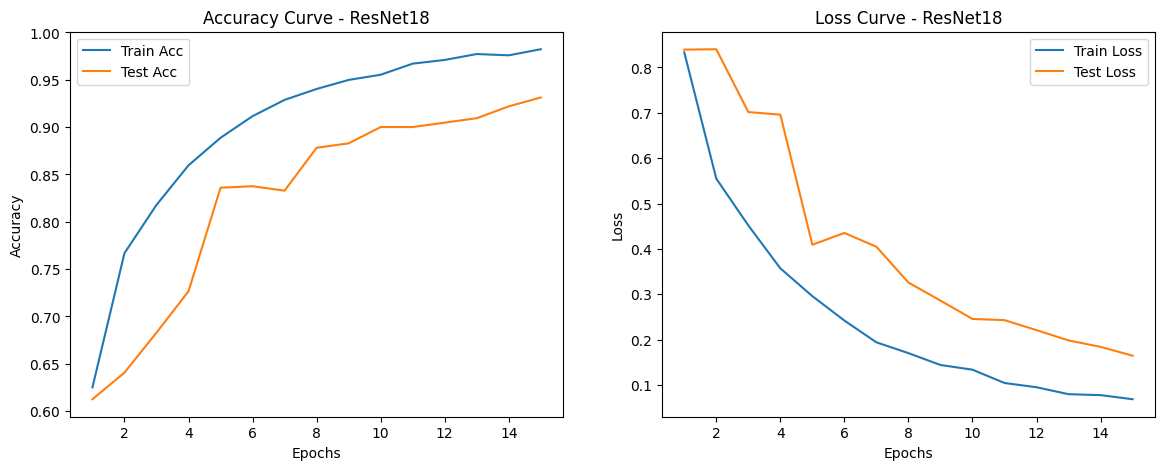


==== Training ResNet50 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Epoch 1/15 | Train Loss: 0.7593 | Train Acc: 0.6748 | Val Loss: 0.7987 | Val Acc: 0.6406 | Test Loss: 0.8205 | Test Acc: 0.6328
Epoch 2/15 | Train Loss: 0.4934 | Train Acc: 0.7959 | Val Loss: 0.6777 | Val Acc: 0.6891 | Test Loss: 0.6844 | Test Acc: 0.6797
Epoch 3/15 | Train Loss: 0.3422 | Train Acc: 0.8639 | Val Loss: 0.4654 | Val Acc: 0.8125 | Test Loss: 0.4614 | Test Acc: 0.8063
Epoch 4/15 | Train Loss: 0.2653 | Train Acc: 0.8920 | Val Loss: 0.4005 | Val Acc: 0.8406 | Test Loss: 0.3851 | Test Acc: 0.8359
Epoch 5/15 | Train Loss: 0.2055 | Train Acc: 0.9240 | Val Loss: 0.2670 | Val Acc: 0.9000 | Test Loss: 0.2966 | Test Acc: 0.8875
Epoch 6/15 | Train Loss: 0.1596 | Train Acc: 0.9395 | Val Loss: 0.2253 | Val Acc: 0.9156 | Test Loss: 0.2447 | Test Acc: 0.8953
Epoch 7/15 | Train Loss: 0.1232 | Train Acc: 0.9525 | Val Loss: 0.1876 | Val Acc: 0.9266 | Test Loss: 0.1980 | Test Acc: 0.9250
Epoch 8/15 | Train Loss: 0.1058 | Train Acc: 0.9633 | Val Loss: 0.2098 | Val Acc: 0.9109 | Test Loss: 0.

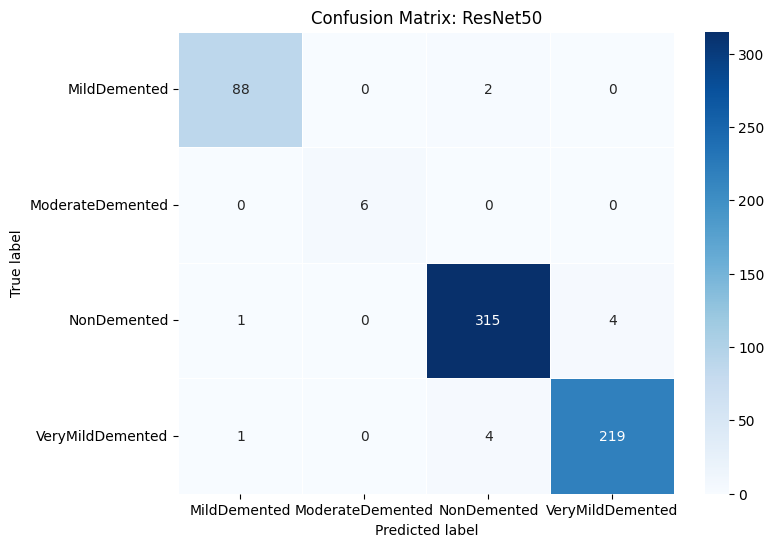

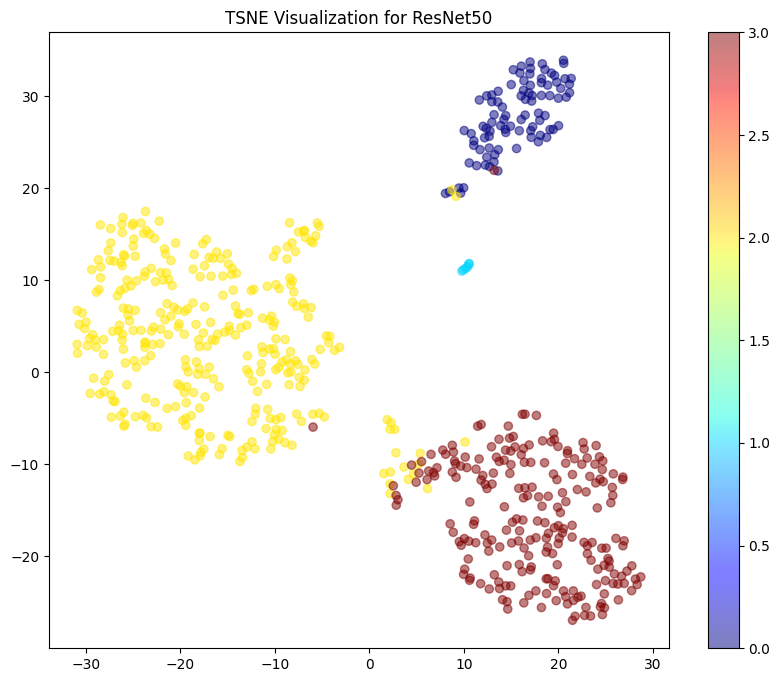

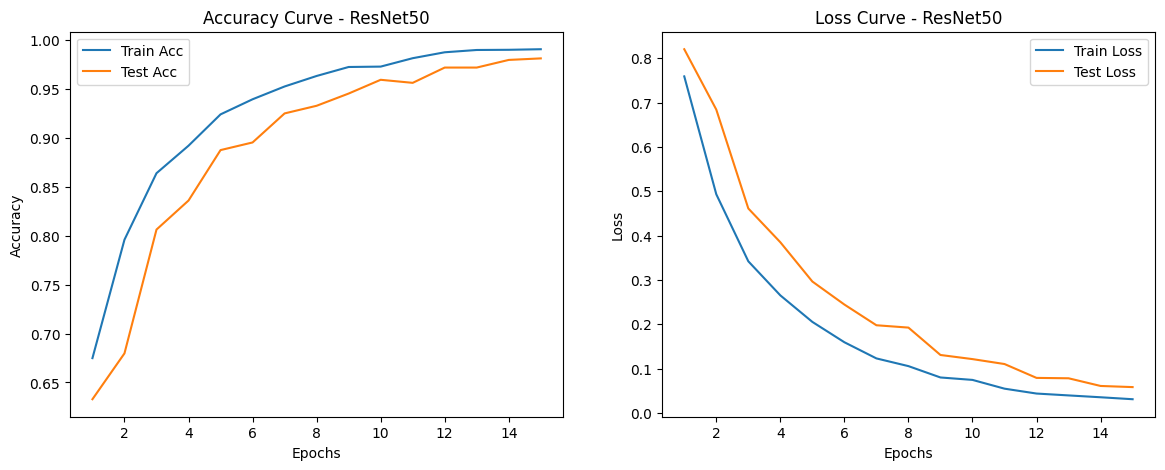


==== Training EfficientNetB3 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 137MB/s] 


Epoch 1/15 | Train Loss: 1.2943 | Train Acc: 0.4102 | Val Loss: 1.1852 | Val Acc: 0.5156 | Test Loss: 1.2054 | Test Acc: 0.4813
Epoch 2/15 | Train Loss: 0.9338 | Train Acc: 0.6100 | Val Loss: 0.9414 | Val Acc: 0.5469 | Test Loss: 0.9787 | Test Acc: 0.5156
Epoch 3/15 | Train Loss: 0.7253 | Train Acc: 0.6742 | Val Loss: 0.8277 | Val Acc: 0.6266 | Test Loss: 0.8534 | Test Acc: 0.5969
Epoch 4/15 | Train Loss: 0.6403 | Train Acc: 0.7137 | Val Loss: 0.7833 | Val Acc: 0.6266 | Test Loss: 0.8027 | Test Acc: 0.6547
Epoch 5/15 | Train Loss: 0.6023 | Train Acc: 0.7350 | Val Loss: 0.7312 | Val Acc: 0.6500 | Test Loss: 0.7441 | Test Acc: 0.6781
Epoch 6/15 | Train Loss: 0.5518 | Train Acc: 0.7627 | Val Loss: 0.6976 | Val Acc: 0.6937 | Test Loss: 0.7050 | Test Acc: 0.7031
Epoch 7/15 | Train Loss: 0.4997 | Train Acc: 0.7883 | Val Loss: 0.6150 | Val Acc: 0.7375 | Test Loss: 0.6165 | Test Acc: 0.7391
Epoch 8/15 | Train Loss: 0.4618 | Train Acc: 0.8113 | Val Loss: 0.5768 | Val Acc: 0.7641 | Test Loss: 0.

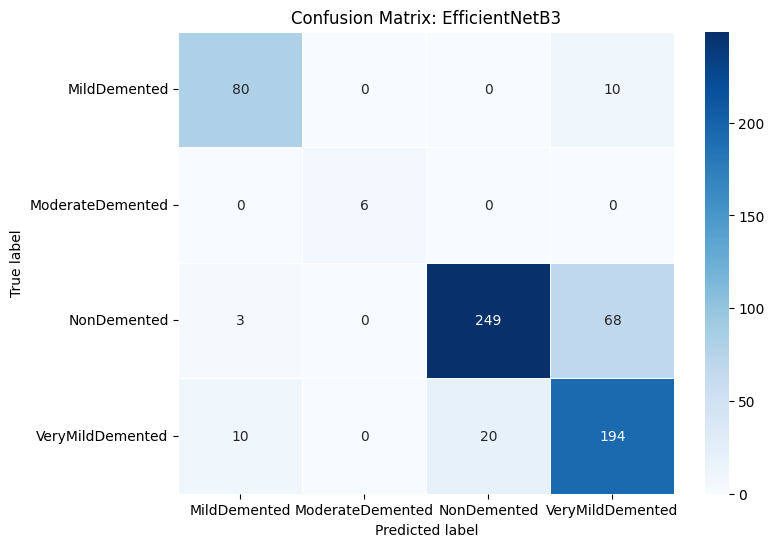

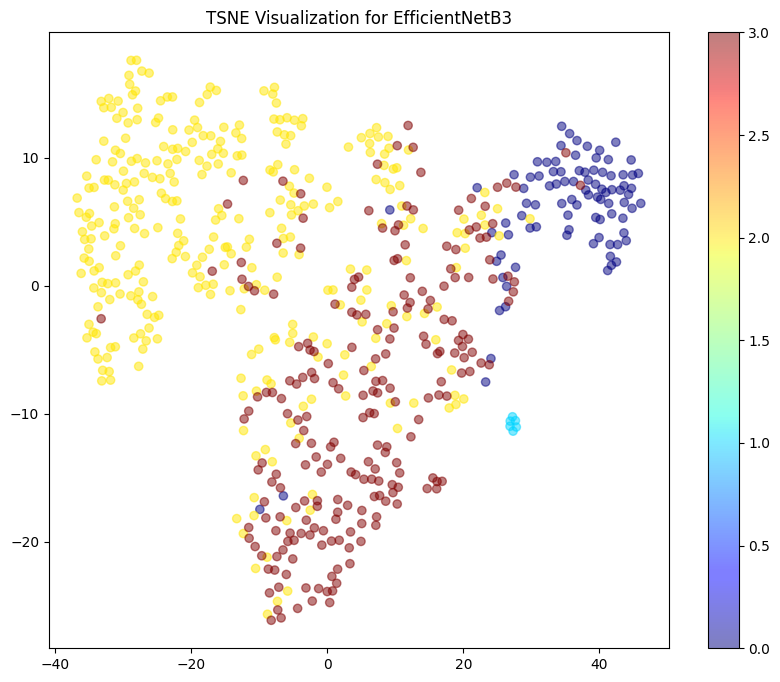

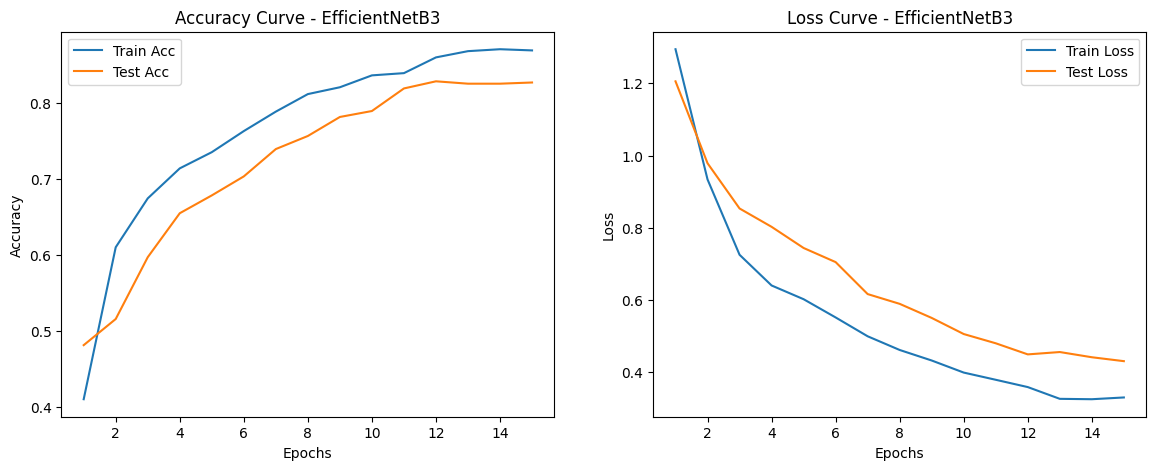

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth



==== Training DenseNet ====


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


Epoch 1/15 | Train Loss: 0.8793 | Train Acc: 0.6348 | Val Loss: 0.8427 | Val Acc: 0.6391 | Test Loss: 0.8775 | Test Acc: 0.6172
Epoch 2/15 | Train Loss: 0.5737 | Train Acc: 0.7609 | Val Loss: 0.7243 | Val Acc: 0.6687 | Test Loss: 0.7636 | Test Acc: 0.6562
Epoch 3/15 | Train Loss: 0.4259 | Train Acc: 0.8316 | Val Loss: 0.6297 | Val Acc: 0.7094 | Test Loss: 0.6640 | Test Acc: 0.7250
Epoch 4/15 | Train Loss: 0.3332 | Train Acc: 0.8736 | Val Loss: 0.4783 | Val Acc: 0.8078 | Test Loss: 0.5204 | Test Acc: 0.7844
Epoch 5/15 | Train Loss: 0.2512 | Train Acc: 0.9070 | Val Loss: 0.3614 | Val Acc: 0.8531 | Test Loss: 0.3796 | Test Acc: 0.8578
Epoch 6/15 | Train Loss: 0.2053 | Train Acc: 0.9275 | Val Loss: 0.3447 | Val Acc: 0.8641 | Test Loss: 0.3212 | Test Acc: 0.8781
Epoch 7/15 | Train Loss: 0.1668 | Train Acc: 0.9432 | Val Loss: 0.2611 | Val Acc: 0.8953 | Test Loss: 0.2657 | Test Acc: 0.9000
Epoch 8/15 | Train Loss: 0.1266 | Train Acc: 0.9613 | Val Loss: 0.2418 | Val Acc: 0.9031 | Test Loss: 0.

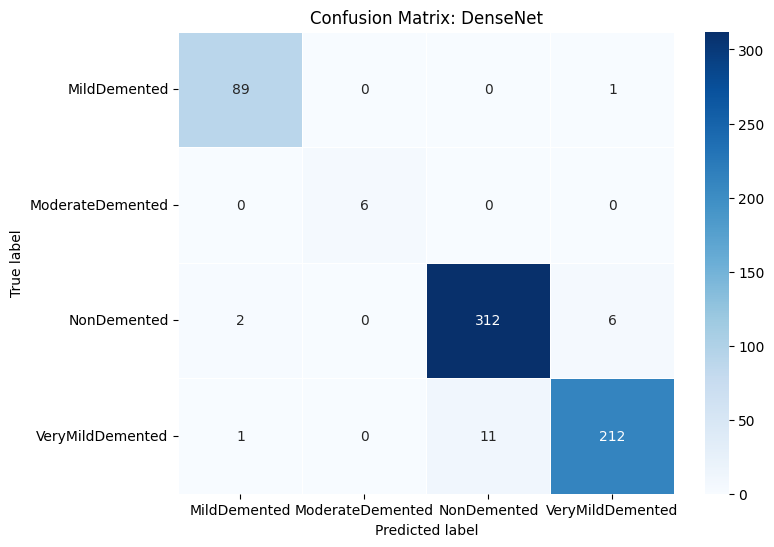

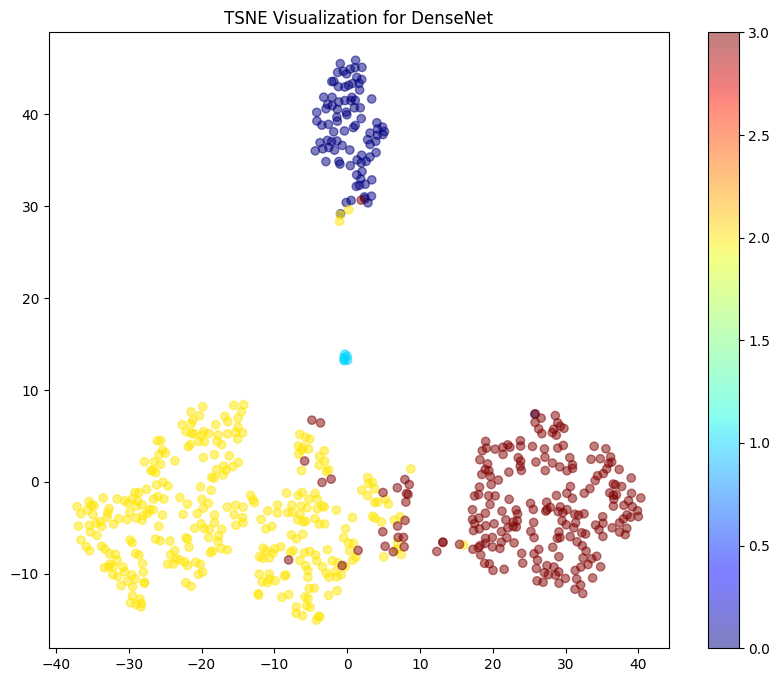

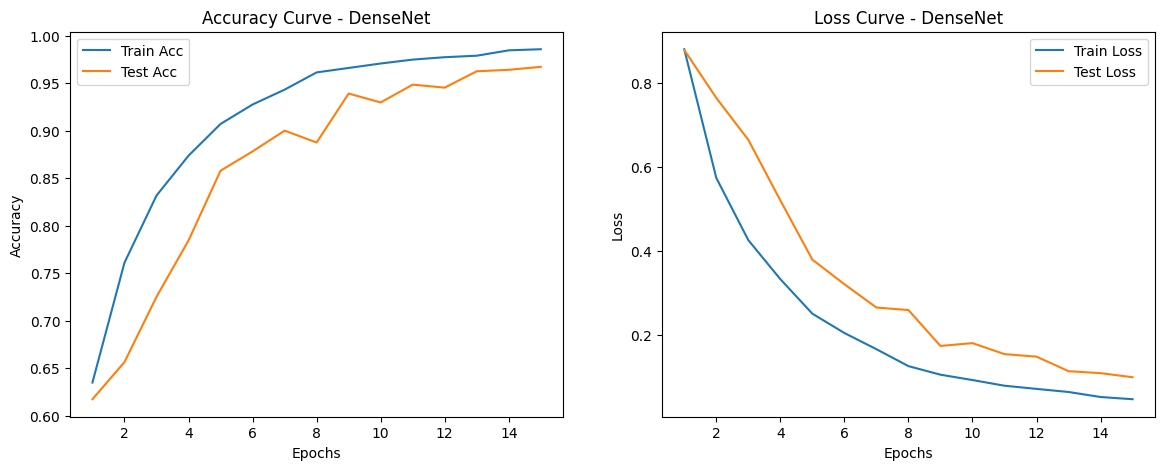


==== Training InceptionV3 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 204MB/s] 


RuntimeError: Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5). Kernel size can't be greater than actual input size

In [12]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix, cohen_kappa_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Data Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model Definitions ----------------------
def create_model(model_name, num_classes):
     if model_name == 'InceptionV3':
        model = models.inception_v3(pretrained=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'VGG16':
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

     elif model_name == 'ResNet18':
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'ResNet50':
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'EfficientNetB3':
        model = models.efficientnet_b3(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

     elif model_name == 'DenseNet':
        model = models.densenet121(pretrained=True)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

  

     return model.to(device)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, total_loss / total, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
def train_model(model_name, model, criterion, optimizer, scheduler, num_epochs=15):
    train_losses, val_losses, test_losses = [], [], []
    train_accs, val_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            running_corrects += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects / total_train
        val_acc, val_loss, val_preds, val_labels = evaluate(val_loader, model, criterion)
        test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        scheduler.step()

    return model, train_losses, val_losses, test_losses, train_accs, val_accs, test_accs, test_preds, test_labels

# ---------------------- Confusion Matrix ----------------------
def plot_confusion_matrix(test_labels, test_preds, classes, model_name):
    cm = confusion_matrix(test_labels, test_preds)
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# ---------------------- TSNE Visualization ----------------------
def plot_tsne(model, test_loader, model_name):
    model.eval()
    features, labels = [], []

    with torch.no_grad():
        for images, lbls in test_loader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.cpu().numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    tsne = TSNE(n_components=2, random_state=0)
    tsne_results = tsne.fit_transform(features)

    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='jet', alpha=0.5)
    plt.title(f"TSNE Visualization for {model_name}")
    plt.colorbar()
    plt.show()

# ---------------------- Plot Accuracy & Loss Curves ----------------------
def plot_curves(train_accs,test_accs, train_losses, test_losses, model_name):
    epochs = range(1, len(train_accs)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accs, label='Train Acc')
   
    plt.plot(epochs, test_accs, label='Test Acc')
    plt.title(f"Accuracy Curve - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
   
    plt.plot(epochs, test_losses, label='Test Loss')
    plt.title(f"Loss Curve - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# ---------------------- Training and Evaluating Each Model ----------------------
model_names = ['VGG16', 'ResNet18', 'ResNet50', 'EfficientNetB3', 'DenseNet', 'InceptionV3']
results = {}

for model_name in model_names:
    print(f"\n==== Training {model_name} ====")
    model = create_model(model_name, len(train_dataset.classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    model, train_losses, val_losses, test_losses, train_accs, val_accs, test_accs, test_preds, test_labels = train_model(
        model_name, model, criterion, optimizer, scheduler, num_epochs=15)

    precision = precision_score(test_labels, test_preds, average='weighted')
    recall = recall_score(test_labels, test_preds, average='weighted')
    f1 = f1_score(test_labels, test_preds, average='weighted')
    kappa = cohen_kappa_score(test_labels, test_preds)

    results[model_name] = {
        'train_acc': train_accs[-1], 'val_acc': val_accs[-1], 'test_acc': test_accs[-1],
        'precision': precision, 'recall': recall, 'f1': f1, 'kappa': kappa
    }

    print(f"\nResults for {model_name}:")
    print(f"Train Accuracy: {train_accs[-1]:.4f}, Val Accuracy: {val_accs[-1]:.4f}, Test Accuracy: {test_accs[-1]:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, Cohen's Kappa: {kappa:.4f}")

    plot_confusion_matrix(test_labels, test_preds, test_dataset.classes, model_name)
    plot_tsne(model, test_loader, model_name)
    plot_curves(train_accs,test_accs, train_losses,test_losses, model_name)

# ---------------------- Display Results ----------------------
print("\nOverall Results:")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f" Train Acc: {metrics['train_acc']:.4f} | "
          f"Val Acc: {metrics['val_acc']:.4f} | "
          f"Test Acc: {metrics['test_acc']:.4f} | "
          f"Precision: {metrics['precision']:.4f} | "
          f"Recall: {metrics['recall']:.4f} | "
          f"F1 Score: {metrics['f1']:.4f} | "
          f"Kappa: {metrics['kappa']:.4f}")
    print("-" * 40)


Epoch 1/15 | Train Loss: 0.9337 | Train Acc: 0.5801 | Val Loss: 0.8446 | Val Acc: 0.6219 | Test Loss: 0.8610 | Test Acc: 0.5797
Epoch 2/15 | Train Loss: 0.6193 | Train Acc: 0.7236 | Val Loss: 0.6897 | Val Acc: 0.6922 | Test Loss: 0.7353 | Test Acc: 0.6609
Epoch 3/15 | Train Loss: 0.4461 | Train Acc: 0.8125 | Val Loss: 0.5286 | Val Acc: 0.7766 | Test Loss: 0.5906 | Test Acc: 0.7250
Epoch 4/15 | Train Loss: 0.3183 | Train Acc: 0.8770 | Val Loss: 0.4843 | Val Acc: 0.7875 | Test Loss: 0.5470 | Test Acc: 0.7719
Epoch 5/15 | Train Loss: 0.2382 | Train Acc: 0.9121 | Val Loss: 0.3215 | Val Acc: 0.8719 | Test Loss: 0.3663 | Test Acc: 0.8609
Epoch 6/15 | Train Loss: 0.1831 | Train Acc: 0.9303 | Val Loss: 0.2946 | Val Acc: 0.8922 | Test Loss: 0.3204 | Test Acc: 0.8641
Epoch 7/15 | Train Loss: 0.1604 | Train Acc: 0.9379 | Val Loss: 0.2384 | Val Acc: 0.9062 | Test Loss: 0.2781 | Test Acc: 0.8922
Epoch 8/15 | Train Loss: 0.1056 | Train Acc: 0.9658 | Val Loss: 0.2421 | Val Acc: 0.9094 | Test Loss: 0.

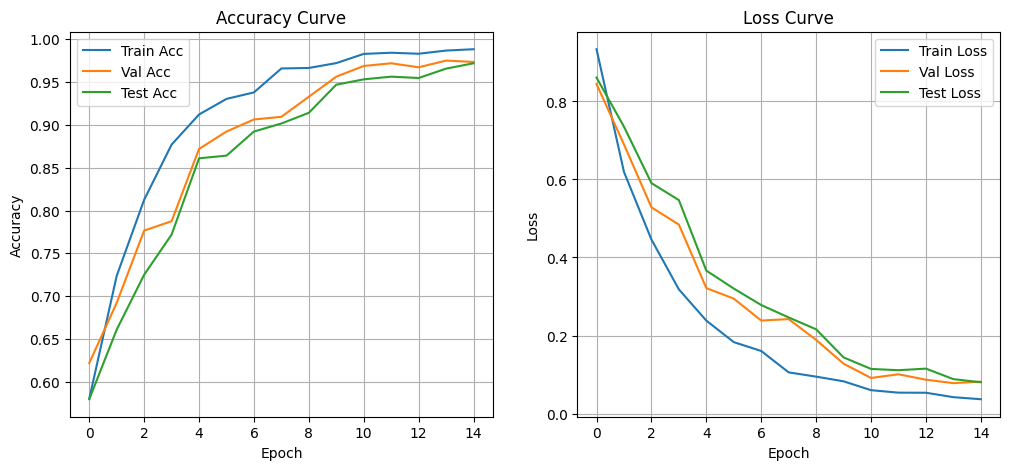

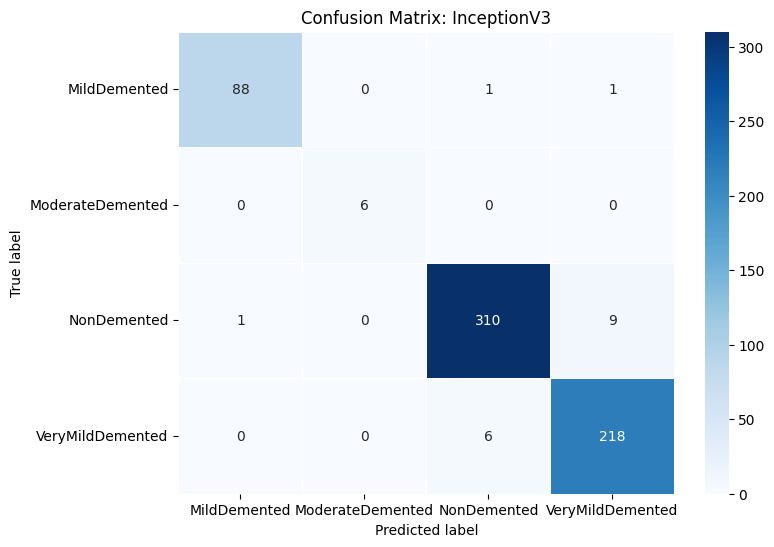

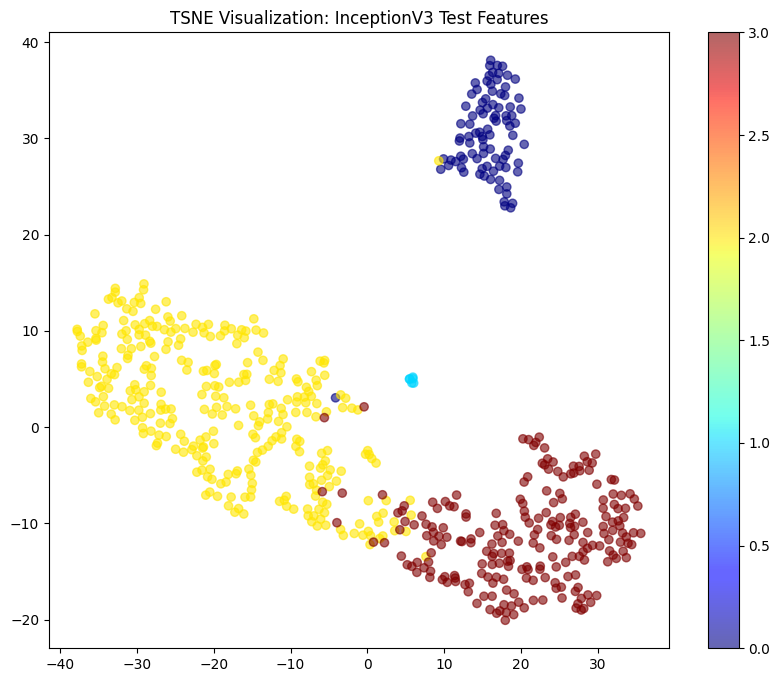

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model ----------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
num_classes = len(train_dataset.classes)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ---------------------- Loss and Optimizer ----------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / total
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
num_epochs = 15
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects / total_train
    val_acc, val_loss, _, _ = evaluate(val_loader, model, criterion)
    test_acc, test_loss, _, _ = evaluate(test_loader, model, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    scheduler.step()

# ---------------------- Accuracy & Loss Curves ----------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.plot(test_accs, label='Test Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------- Confusion Matrix ----------------------
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)
cm = confusion_matrix(test_labels, test_preds)
df_cm = pd.DataFrame(cm, index=train_dataset.classes, columns=train_dataset.classes)
plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix: InceptionV3")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ---------------------- TSNE Visualization ----------------------
model.eval()
features, labels = [], []
with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        features.append(outputs.cpu().numpy())
        labels.append(lbls.cpu().numpy())

features = np.concatenate(features)
labels = np.concatenate(labels)

tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10,8))
plt.scatter(tsne_results[:,0], tsne_results[:,1], c=labels, cmap='jet', alpha=0.6)
plt.title('TSNE Visualization: InceptionV3 Test Features')
plt.colorbar()
plt.show()


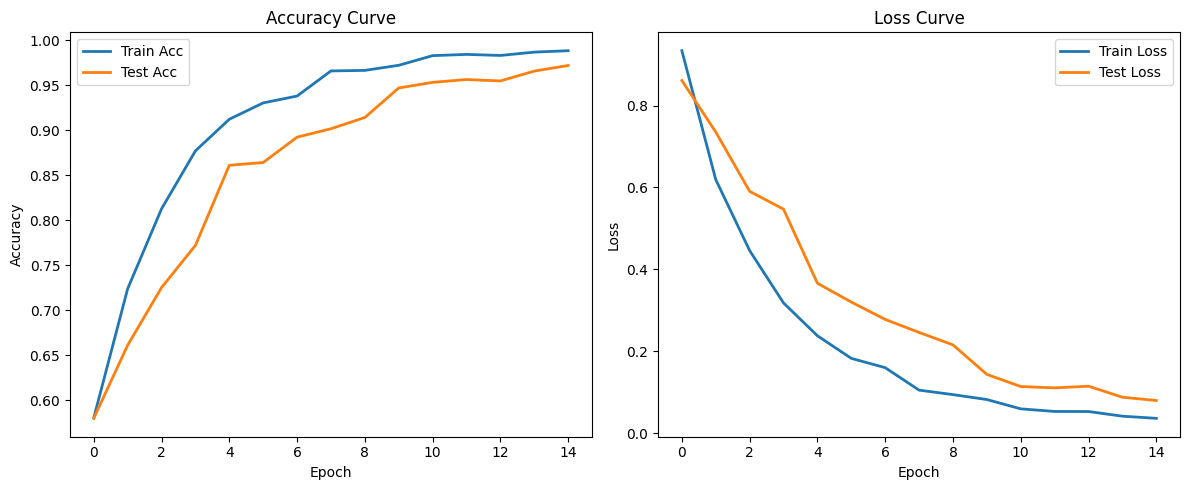

In [22]:
# ---------------------- Accuracy & Loss Curves ----------------------
plt.figure(figsize=(12,5))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Acc', linewidth=2)
plt.plot(test_accs, label='Test Acc', linewidth=2)
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False)  # Remove background grid/boxes

# Loss Curve
plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)  # Remove background grid/boxes

plt.tight_layout()
plt.show()


Epoch 1/15 | Train Loss: 0.9382 | Train Acc: 0.5906 | Val Loss: 0.8548 | Val Acc: 0.6172 | Test Loss: 0.8667 | Test Acc: 0.5953
Epoch 2/15 | Train Loss: 0.5935 | Train Acc: 0.7375 | Val Loss: 0.6849 | Val Acc: 0.7063 | Test Loss: 0.6951 | Test Acc: 0.7031
Epoch 3/15 | Train Loss: 0.4300 | Train Acc: 0.8201 | Val Loss: 0.5350 | Val Acc: 0.7688 | Test Loss: 0.5309 | Test Acc: 0.7562
Epoch 4/15 | Train Loss: 0.3089 | Train Acc: 0.8773 | Val Loss: 0.4684 | Val Acc: 0.8109 | Test Loss: 0.4662 | Test Acc: 0.8125
Epoch 5/15 | Train Loss: 0.2337 | Train Acc: 0.9182 | Val Loss: 0.3820 | Val Acc: 0.8625 | Test Loss: 0.3771 | Test Acc: 0.8547
Epoch 6/15 | Train Loss: 0.1789 | Train Acc: 0.9352 | Val Loss: 0.2612 | Val Acc: 0.9016 | Test Loss: 0.2501 | Test Acc: 0.9047
Epoch 7/15 | Train Loss: 0.1326 | Train Acc: 0.9520 | Val Loss: 0.2513 | Val Acc: 0.9000 | Test Loss: 0.2624 | Test Acc: 0.9000
Epoch 8/15 | Train Loss: 0.1033 | Train Acc: 0.9682 | Val Loss: 0.2178 | Val Acc: 0.9172 | Test Loss: 0.

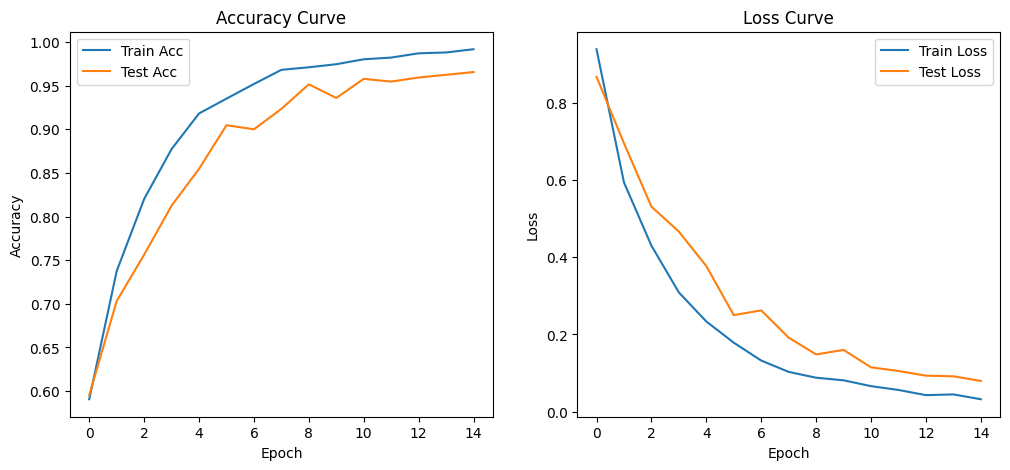

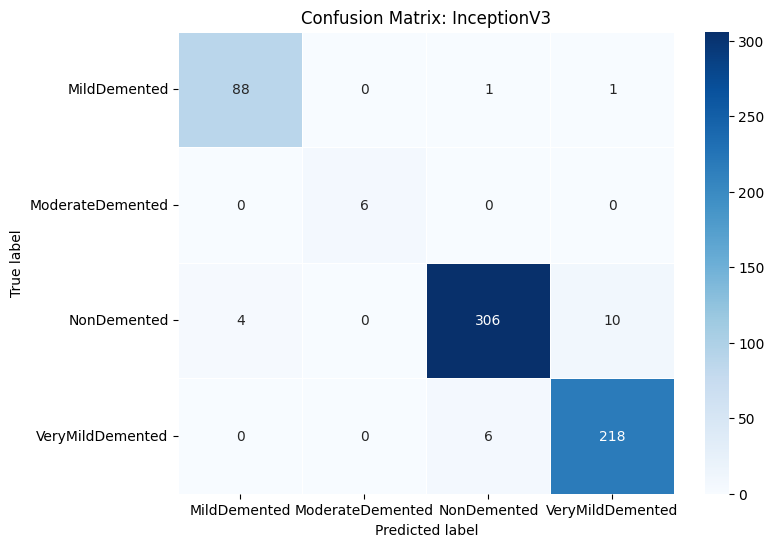

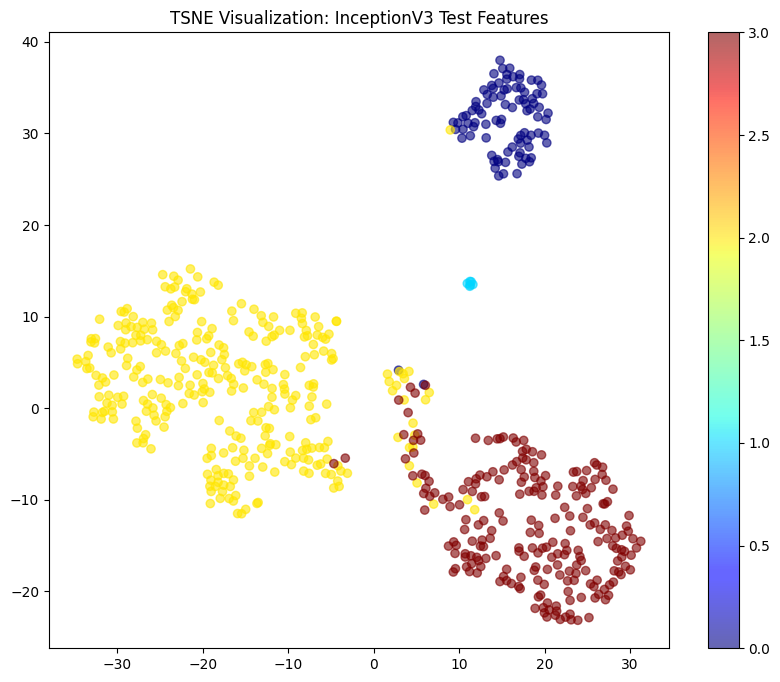


=== InceptionV3 Evaluation Metrics ===
Train Accuracy: 0.9965 | Precision: 0.9965 | Recall: 0.9965 | F1 Score: 0.9965 | Cohen's Kappa: 0.9953
Val Accuracy:   0.9625 | Precision: 0.9627 | Recall: 0.9625 | F1 Score: 0.9625 | Cohen's Kappa: 0.9385
Test Accuracy:  0.9656 | Precision: 0.9659 | Recall: 0.9656 | F1 Score: 0.9656 | Cohen's Kappa: 0.9436

Metrics saved to /kaggle/working/inceptionv3_metrics_summary.csv


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model ----------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
num_classes = len(train_dataset.classes)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ---------------------- Loss and Optimizer ----------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / total
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
num_epochs = 15
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects / total_train
    val_acc, val_loss, _, _ = evaluate(val_loader, model, criterion)
    test_acc, test_loss, _, _ = evaluate(test_loader, model, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    scheduler.step()

# ---------------------- Accuracy & Loss Curves ----------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Acc')

plt.plot(test_accs, label='Test Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False)  # Remove background boxes

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')

plt.plot(test_losses, label='Test Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

# ---------------------- Confusion Matrix ----------------------
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)
cm = confusion_matrix(test_labels, test_preds)
df_cm = pd.DataFrame(cm, index=train_dataset.classes, columns=train_dataset.classes)
plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix: InceptionV3")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ---------------------- TSNE Visualization ----------------------
model.eval()
features, labels = [], []
with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        features.append(outputs.cpu().numpy())
        labels.append(lbls.cpu().numpy())

features = np.concatenate(features)
labels = np.concatenate(labels)

tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10,8))
plt.scatter(tsne_results[:,0], tsne_results[:,1], c=labels, cmap='jet', alpha=0.6)
plt.title('TSNE Visualization: InceptionV3 Test Features')
plt.colorbar()
plt.show()

# ---------------------- Final Evaluation Metrics ----------------------
train_acc, train_loss, train_preds, train_labels = evaluate(train_loader, model, criterion)
val_acc, val_loss, val_preds, val_labels = evaluate(val_loader, model, criterion)
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)

# Metrics calculation
train_precision = precision_score(train_labels, train_preds, average='weighted')
train_recall = recall_score(train_labels, train_preds, average='weighted')
train_f1 = f1_score(train_labels, train_preds, average='weighted')
train_kappa = cohen_kappa_score(train_labels, train_preds)

val_precision = precision_score(val_labels, val_preds, average='weighted')
val_recall = recall_score(val_labels, val_preds, average='weighted')
val_f1 = f1_score(val_labels, val_preds, average='weighted')
val_kappa = cohen_kappa_score(val_labels, val_preds)

test_precision = precision_score(test_labels, test_preds, average='weighted')
test_recall = recall_score(test_labels, test_preds, average='weighted')
test_f1 = f1_score(test_labels, test_preds, average='weighted')
test_kappa = cohen_kappa_score(test_labels, test_preds)

# Print metrics
print("\n=== InceptionV3 Evaluation Metrics ===")
print(f"Train Accuracy: {train_acc:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1 Score: {train_f1:.4f} | Cohen's Kappa: {train_kappa:.4f}")
print(f"Val Accuracy:   {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1 Score: {val_f1:.4f} | Cohen's Kappa: {val_kappa:.4f}")
print(f"Test Accuracy:  {test_acc:.4f} | Precision: {test_precision:.4f} | Recall: {test_recall:.4f} | F1 Score: {test_f1:.4f} | Cohen's Kappa: {test_kappa:.4f}")

# ---------------------- Save metrics to CSV ----------------------
results_df = pd.DataFrame({
    "Model": ["InceptionV3"],
    "Train Accuracy": [train_acc],
    "Train Precision": [train_precision],
    "Train Recall": [train_recall],
    "Train F1 Score": [train_f1],
    "Train Kappa": [train_kappa],
    "Val Accuracy": [val_acc],
    "Val Precision": [val_precision],
    "Val Recall": [val_recall],
    "Val F1 Score": [val_f1],
    "Val Kappa": [val_kappa],
    "Test Accuracy": [test_acc],
    "Test Precision": [test_precision],
    "Test Recall": [test_recall],
    "Test F1 Score": [test_f1],
    "Test Kappa": [test_kappa],
})

results_df.to_csv("/kaggle/working/inceptionv3_metrics_summary.csv", index=False)
print("\nMetrics saved to /kaggle/working/inceptionv3_metrics_summary.csv")
